In [34]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [35]:
data_dir = Path("../data")
silver_dir = data_dir / "bronze"
df = pd.read_csv(silver_dir / "kddcup_testdata_unlabeled_10_percent.csv")

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print(df.head())

   duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
0         0              2       46     9        105        146     0   
1         0              2       46     9        105        146     0   
2         0              2       46     9        105        146     0   
3         0              2       46     9        105        146     0   
4         0              2       46     9        105        146     0   

   wrong_fragment  urgent  hot  ...  dst_host_count  dst_host_srv_count  \
0               0       0    0  ...             255                 254   
1               0       0    0  ...             255                 254   
2               0       0    0  ...             255                 254   
3               0       0    0  ...             255                 254   
4               0       0    0  ...             255                 254   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                    0.01   
1   

In [36]:
inertia = []
scores = []

K = range(2, 11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        init='k-means++',
        n_init=10
    )
    model.fit(df)
    inertia.append(model.inertia_)
    # labels = model.predict(df)
    # score = silhouette_score(df, labels)
    # scores.append(score)

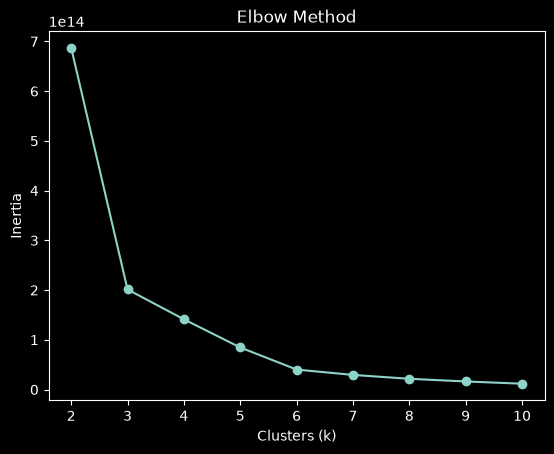

In [37]:
plt.plot(K, inertia, marker='o')
plt.xlabel("Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [38]:
# plt.plot(K, scores, marker='o')
# plt.xlabel("k")
# plt.ylabel("Silhouette score")
# plt.title("Silhouette analysis")
# plt.show()

In [39]:
# import numpy as np
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler
#
# X = StandardScaler().fit_transform(df)
# X_reduced = PCA(n_components=5).fit_transform(X)
# dbscan_model = DBSCAN(eps=2, min_samples=3)
# dbscan_result = dbscan_model.fit_predict(X_reduced)
# dbscan_clusters = np.unique(dbscan_result)
# df['cluster'] = dbscan_result
# df['cluster'].value_counts()